# Movie Dataset Analysis

The goal of this project is to explore factors related to movie
performance, including revenue, popularity, ratings, language,
and release trends.

# Setup and Data Loading.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
df = pd.read_csv('movies_metadata.csv', low_memory=False)

In [3]:
sns.set_style("whitegrid")
sns.set_context("talk")

# Data Overview

In [4]:
df.shape
df.head()
df.info()
df.columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

,revenue,runtime,vote_average,vote_count
count,4.546000e+04,45203.000000,45460.000000,45460.000000
mean,1.120935e+07,94.128199,5.618207,109.897338
std,6.433225e+07,38.407810,1.924216,491.310374
min,0.000000e+00,0.000000,0.000000,0.000000
25%,0.000000e+00,85.000000,5.000000,3.000000
50%,0.000000e+00,95.000000,6.000000,10.000000
75%,0.000000e+00,107.000000,6.800000,34.000000
max,2.787965e+09,1256.000000,10.000000,14075.000000


# Data Cleaning & Preparation

## ID & Financial variables.

The `budget` and `revenue` columns contained mixed data types and could not be used directly for numerical analysis.

To prepare these variables for analysis:

- Converted `id`, `budget`, and `revenue` to numeric data types.
- Coerced invalid values to `NaN`.
- Removed records with invalid movie IDs.
- Reviewed the number of missing values remaining in the financial variables.

In [5]:
# Convert ID column values to numeric values
df['id'] = pd.to_numeric(df['id'], errors='coerce')

# Remove records with invalid IDs
rows_before = len(df)
df = df.dropna(subset=['id'])
rows_after = len(df)
print(f"Rows removed: {rows_before - rows_after}")

# Inspect duplicates
duplicate_rows = df[df.duplicated(subset=["id"], keep=False)].sort_values("id")
display(duplicate_rows.head(4))

# Count duplicates before cleaning 
duplicates = df.duplicated(subset=["id"], keep=False)
print("Duplicate ID count:", duplicates.sum())

# Remove duplicates
df = df.drop_duplicates(subset=["id"])

duplicates_after = df.duplicated(subset=["id"], keep=False)

# Validation
print("Duplicate ID count after dropping:", duplicates_after.sum())

Rows removed: 3


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
33826,False,NaN,30000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 80, 'nam...",NaN,4912.0,tt0270288,en,Confessions of a Dangerous Mind,"Television made him famous, but his biggest hi...",...,2002-12-30,33013805.0,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Some things are better left top secret.,Confessions of a Dangerous Mind,False,6.6,281.0
5865,False,NaN,30000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 80, 'nam...",NaN,4912.0,tt0270288,en,Confessions of a Dangerous Mind,"Television made him famous, but his biggest hi...",...,2002-12-30,33013805.0,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Some things are better left top secret.,Confessions of a Dangerous Mind,False,6.6,281.0
9165,False,NaN,0,"[{'id': 80, 'name': 'Crime'}, {'id': 18, 'name...",NaN,5511.0,tt0062229,fr,Le Samouraï,Hitman Jef Costello is a perfectionist who alw...,...,1967-10-25,39481.0,105.0,"[{'iso_639_1': 'fr', 'name': 'Français'}]",Released,There is no solitude greater than that of the ...,Le Samouraï,False,7.9,187.0
7345,False,NaN,0,"[{'id': 80, 'name': 'Crime'}, {'id': 18, 'name...",NaN,5511.0,tt0062229,fr,Le Samouraï,Hitman Jef Costello is a perfectionist who alw...,...,1967-10-25,39481.0,105.0,"[{'iso_639_1': 'fr', 'name': 'Français'}]",Released,There is no solitude greater than that of the ...,Le Samouraï,False,7.9,187.0


Duplicate ID count: 59
Duplicate ID count after dropping: 0


In [6]:
# Convert finance variables to numeric values
df['budget'] = pd.to_numeric(df['budget'], errors='coerce')
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

# Validation

print('budget NaN values:',df['budget'].isna().sum())
print('revenue NaN values:',df['revenue'].isna().sum())

budget NaN values: 0
revenue NaN values: 3


## Language Feature Engineering

The dataset includes the original language of each movie.

To simplify later analysis, a binary feature was created to identify
whether a movie was originally released in English.

In [7]:
# Binary flag for English-language movies
df['is_english_original'] = (df['original_language'] == 'en').astype(int)

# Validation
display(df['is_english_original'].value_counts())

1    32251
0    13182
Name: is_english_original, dtype: int64

## Popularity Variable

The popularity column contained formatting inconsistencies and was stored as a non-numeric value in some records.

The variable was cleaned and converted to numeric format so it could be used in descriptive statistics and visualizations.

In [8]:
# Popularity cleaning, fixing issues and convert to numeric
df['popularity'] = (
    df['popularity']
    .astype(str)
    .str.replace(',', '')
)
df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce')

# Validation
display(df['popularity'].describe())

count    45430.000000
mean         2.921206
std          6.006708
min          0.000000
25%          0.385872
50%          1.127238
75%          3.678127
max        547.488298
Name: popularity, dtype: float64

## Date Features

The `release_date` column was originally stored as a object value and could not be used directly for time-based analysis.

To support temporal analysis:

- Converted `release_date` to a datetime format.
- Extracted the release year.
- Filtered the dataset to movies released from 1980 onward.
- Created a `decade` feature to analyze trends across time periods.

These features will be used later to explore changes in financial performance over time.

In [9]:
# Convert release date to datetime
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

# Create decade feature
df['year_release_date'] = df['release_date'].dt.year
df = df[df['release_date'].dt.year >= 1980]
df['decade'] = (df['year_release_date']//10)*10
df['decade'] = df['decade'].astype(int)

# Validation
print(
    f"Release year range: "
    f"{df['year_release_date'].min()} - "
    f"{df['year_release_date'].max()}"
)

display(
    df[['year_release_date', 'decade']]
    .sample(5)
)

Release year range: 1980.0 - 2020.0


,year_release_date,decade
6813,2002.0,2000
34375,2012.0,2010
23604,1998.0,1990
12704,2008.0,2000
40617,2016.0,2010


## Data Quality Validation

After completing the cleaning and feature engineering process, a final validation was performed to assess the overall quality of the dataset.

The validation focuses on:

- Missing values in key analytical variables.
- Data types after transformation.
- Consistency of newly created features.

This step helps ensure the dataset is ready for exploratory analysis and visualization.

In [10]:
# Check if some values are missing
columns = [
    'id',
    'original_title',
    'budget',
    'popularity',
    'revenue',
    'is_english_original',
    'release_date',
    'year_release_date',
    'decade',
    'vote_average',
    'vote_count'
]

df[columns].isna().sum()

id                     0
original_title         0
budget                 0
popularity             0
revenue                0
is_english_original    0
release_date           0
year_release_date      0
decade                 0
vote_average           0
vote_count             0
dtype: int64

## Cleaning Summary

The dataset was cleaned and prepared for analysis through:

- Numeric conversion of financial and identifier variables.
- Creation of language-based features.
- Standardization of popularity values.
- Extraction of time-related features from release dates.
- Validation of missing values and data types.

The dataset is now ready for exploratory analysis and visualization.

# Exploratory Data Analysis

## 1. - Do bigger budgets mean bigger revenue?

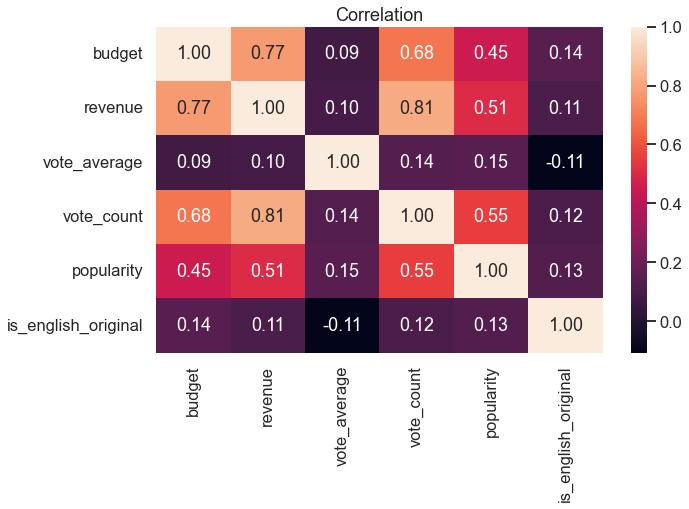

In [11]:
# 1.correlation between budget and revenue
cols_heatmap = ['budget','revenue','vote_average','vote_count','popularity','is_english_original']
df_heatmap = df[cols_heatmap].dropna()
corr_matrix_f1 = df_heatmap.corr()

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(corr_matrix_f1, annot=True, fmt='.2f', ax=ax)
ax.set(title='Correlation')
plt.show()

* Budget and revenue show a strong positive correlation (r = 0.77).
* Higher-budget movies tend to attract more audience engagement, reflected in higher vote counts (r = 0.68).
* Revenue is more strongly associated with vote count (r = 0.81) than with vote average (r = 0.10).
* Original English-language status shows little correlation with financial performance or audience metrics.

## 2. -  Are better-rated movies more profitable?

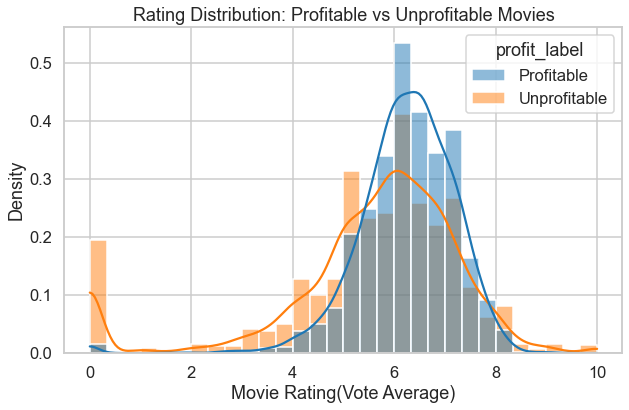

In [12]:
df['is_profitable'] = df['revenue'] > df['budget']
df_clean = df.dropna(subset=['vote_average', 'is_profitable'])

# Make labels easier to read
df_clean['profit_label'] = df_clean['is_profitable'].map({
    True: 'Profitable',
    False: 'Unprofitable'
})
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    x='vote_average',
    hue='profit_label',
    kde=True,
    bins=30,
    stat='density',
    common_norm=False,
    alpha=0.5,
    data=df_clean,
    ax=ax
)
ax.set(title='Rating Distribution: Profitable vs Unprofitable Movies', xlabel='Movie Rating(Vote Average)', ylabel='Density')
plt.show()

* Profitable movies generally receive slightly higher ratings.
* However, the strong overlap between groups indicates that ratings alone do not explain profitability.

## 3. -  How Has Film Revenue Changed Over Time?

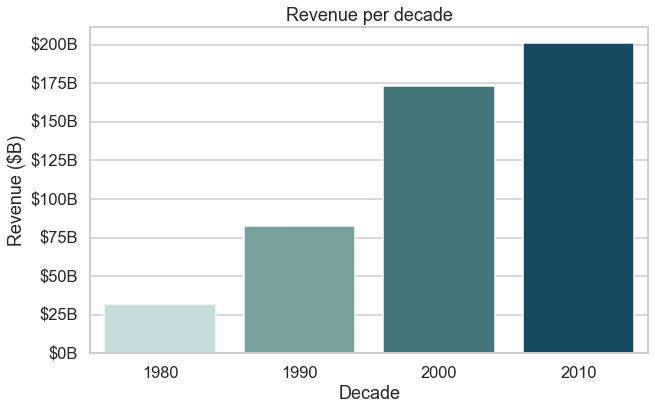

In [13]:
# 3.revenue by decade
df_decades = (
    df.dropna(subset=['decade', 'revenue'])
    .groupby('decade')
    .agg({'revenue':'sum',})
    .reset_index()
)
# Custom color palette by decade
colors = ['#C0E0DE', '#70A9A1', '#3A7D84', '#0B4F6C']
df_decades = df_decades[df_decades['revenue'] != 0]
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data = df_decades, x ='decade', y = 'revenue', palette=colors[:len(df_decades)], ax=ax)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x/1e9:.0f}B'))
ax.set(title='Revenue per decade', xlabel='Decade', ylabel='Revenue ($B)')
plt.show()

* Total revenue shows a clear upward trend from the 1980s through the 2010s.
* The 2010s generated the highest total revenue in the dataset.
* Revenue growth was particularly strong between the 1990s and 2000s.
* No decade represented in the revenue data experienced a decline in total revenue.

## 4. -  Which movies made the most money?

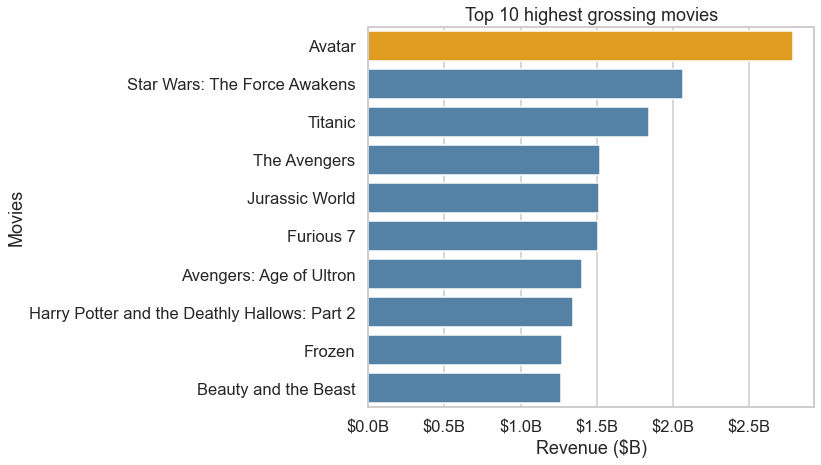

In [17]:
df_sorted_finance_movies = df.sort_values(by='revenue', ascending=False).head(10)
# Create colors list
colors = ['steelblue'] * len(df_sorted_finance_movies)
colors[0] = 'orange'
fig, ax = plt.subplots(figsize=(8,7)) 
sns.barplot(data = df_sorted_finance_movies, x = 'revenue', y = 'original_title', palette=colors, ax=ax)
ax.set(title='Top 10 highest grossing movies', xlabel='Revenue ($B)', ylabel='Movies')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x/1e9:.1f}B'))

* All top 10 movies earned over &#0036;1 billion in revenue.
* Avatar is the highest-grossing movie, clearly outperforming the rest.
* Two entries in the top 10 contain “Avengers” in their titles, suggesting strong recurring performance of the same film series.

# Summary & Insights

This analysis surfaced some genuinely interesting patterns around what drives movie financial performance. Budget had the strongest relationship with revenue — bigger productions tend to earn more, which makes intuitive sense. What surprised me more was that vote count (a measure of audience reach) was actually a slightly stronger revenue predictor than budget itself. Ratings, on the other hand, barely moved the needle on profitability — which I didn't expect going in.

That said, the data has real limitations. Financial records had missing values and inconsistencies, so I'd treat these findings as directional rather than definitive. Correlation isn't causation, and there's a lot this dataset can't tell us on its own.

Overall though, this project gave me a solid foundation in end-to-end exploratory analysis — from messy raw data to patterns worth talking about. There's more to dig into, but the core question — what makes a movie financially successful — turned out to be more nuanced than the numbers alone can answer.